In [1]:
import yfinance as yf

In [2]:
s_data = yf.download("GILLETTE.NS", start="2020-01-01", end="2025-12-03")
print(s_data.head())


C:\Users\ABHIJEET CHANDRA\AppData\Local\Temp\ipykernel_12408\2937702880.py:1: FutureWarning: YF.download() has changed argument auto_adjust default to True
  s_data = yf.download("GILLETTE.NS", start="2020-01-01", end="2025-12-03")
[*********************100%***********************]  1 of 1 completed

Price             Close         High          Low         Open      Volume
Ticker      GILLETTE.NS  GILLETTE.NS  GILLETTE.NS  GILLETTE.NS GILLETTE.NS
Date                                                                      
2020-01-01  6039.583496  6055.466025  6000.632794  6020.268164        1764
2020-01-02  6029.835449  6060.959543  6014.410625  6014.410625        2323
2020-01-03  6015.782715  6064.620161  5995.964083  6029.880007        3646
2020-01-06  6034.641113  6053.635964  5986.810707  6053.635964        3100
2020-01-07  6000.495117  6049.012075  5968.501209  6034.639892        2710


In [3]:
s_data.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 1468 entries, 2020-01-01 to 2025-12-02
Data columns (total 5 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   (Close, GILLETTE.NS)   1468 non-null   float64
 1   (High, GILLETTE.NS)    1468 non-null   float64
 2   (Low, GILLETTE.NS)     1468 non-null   float64
 3   (Open, GILLETTE.NS)    1468 non-null   float64
 4   (Volume, GILLETTE.NS)  1468 non-null   int64  
dtypes: float64(4), int64(1)
memory usage: 68.8 KB


In [4]:
s_data.head()

Price,Close,High,Low,Open,Volume
Ticker,GILLETTE.NS,GILLETTE.NS,GILLETTE.NS,GILLETTE.NS,GILLETTE.NS
Date,,,,,
2020-01-01,6039.583496,6055.466025,6000.632794,6020.268164,1764
2020-01-02,6029.835449,6060.959543,6014.410625,6014.410625,2323
2020-01-03,6015.782715,6064.620161,5995.964083,6029.880007,3646
2020-01-06,6034.641113,6053.635964,5986.810707,6053.635964,3100
2020-01-07,6000.495117,6049.012075,5968.501209,6034.639892,2710


In [5]:
s_data.columns=[i[0] for i in s_data.columns]

In [6]:
import pandas as pd

In [7]:
s_data.reset_index(inplace=True)

In [8]:
s_data[0:10]

,Date,Close,High,Low,Open,Volume
0,2020-01-01,6039.583496,6055.466025,6000.632794,6020.268164,1764
1,2020-01-02,6029.835449,6060.959543,6014.410625,6014.410625,2323
2,2020-01-03,6015.782715,6064.620161,5995.964083,6029.880007,3646
3,2020-01-06,6034.641113,6053.635964,5986.810707,6053.635964,3100
4,2020-01-07,6000.495117,6049.012075,5968.501209,6034.639892,2710
5,2020-01-08,5902.912109,6013.631205,5881.537095,6005.118030,6646
6,2020-01-09,5910.418457,5995.964108,5892.659508,5941.039246,4397
7,2020-01-10,5913.713379,5942.869413,5900.760356,5940.992992,2427
8,2020-01-13,5941.588379,5988.594994,5895.268324,5940.855779,4062
9,2020-01-14,5930.558105,5977.656358,5891.607399,5971.980609,9660


In [9]:
data=s_data.copy()

### Encoding Date

In [10]:
data['Month'] = data['Date'].dt.month

In [11]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [12]:
data['Month_sin'] = np.sin(2 * np.pi * data['Month'] / 12)
data['Month_cos'] = np.cos(2 * np.pi * data['Month'] / 12)

In [13]:
data.drop(["Date","Month"],axis=1,inplace=True)

In [14]:
pd.set_option('display.float_format', '{:,.0f}'.format)

In [15]:
data.isnull().sum()

Close        0
High         0
Low          0
Open         0
Volume       0
Month_sin    0
Month_cos    0
dtype: int64

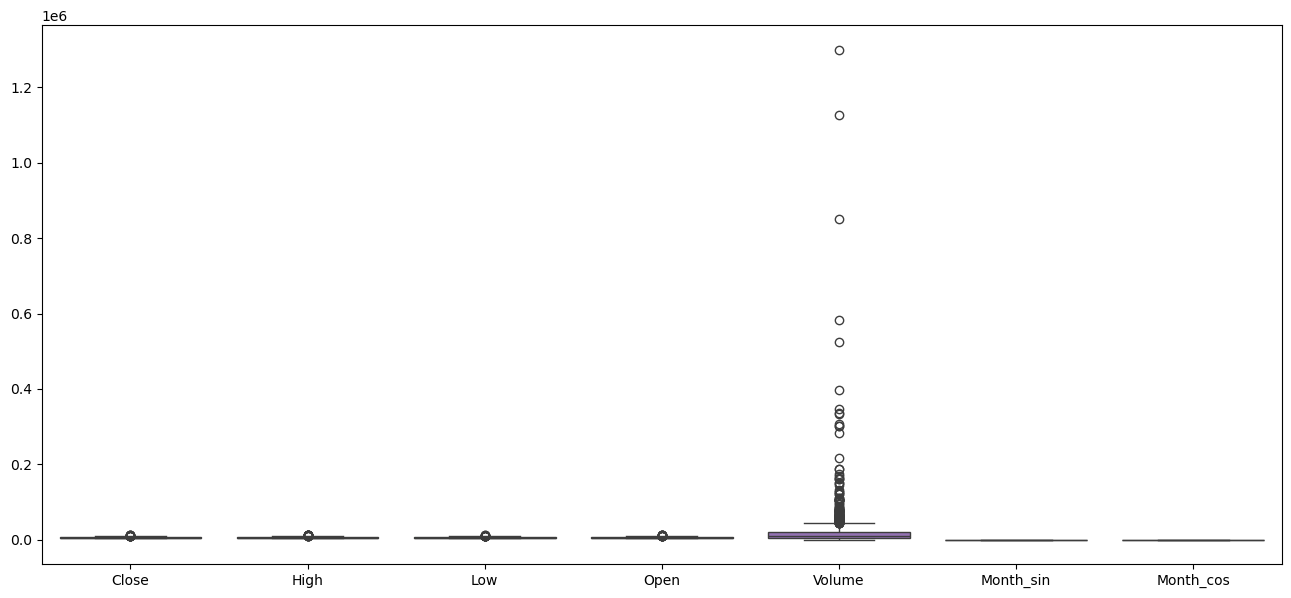

In [16]:
sns.boxplot(data=data)
plt.gcf().set_size_inches(16,7)
plt.show()

In [17]:
# volume column have outliers

data["Volume"]=np.log1p(data["Volume"])


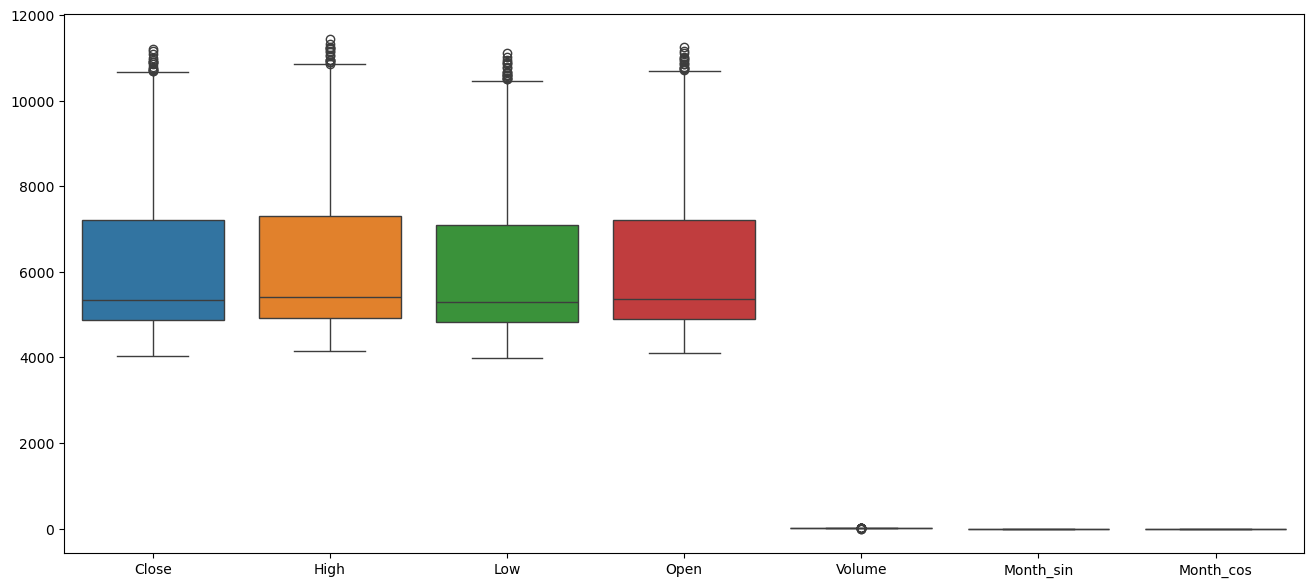

In [18]:
sns.boxplot(data=data)
plt.gcf().set_size_inches(16,7)
plt.show()

### New column Next_Close

In [19]:
data['Next_Close'] = data['Close'].shift(-1)
data.dropna(inplace=True)  # Drop last row (no next day)

In [20]:
x=data.drop(["Next_Close"],axis=1)
y=data["Next_Close"]

### Check Multicorilinity

In [21]:
abs(x.corr())>0.7

,Close,High,Low,Open,Volume,Month_sin,Month_cos
Close,True,True,True,True,False,False,False
High,True,True,True,True,False,False,False
Low,True,True,True,True,False,False,False
Open,True,True,True,True,False,False,False
Volume,False,False,False,False,True,False,False
Month_sin,False,False,False,False,False,True,False
Month_cos,False,False,False,False,False,False,True


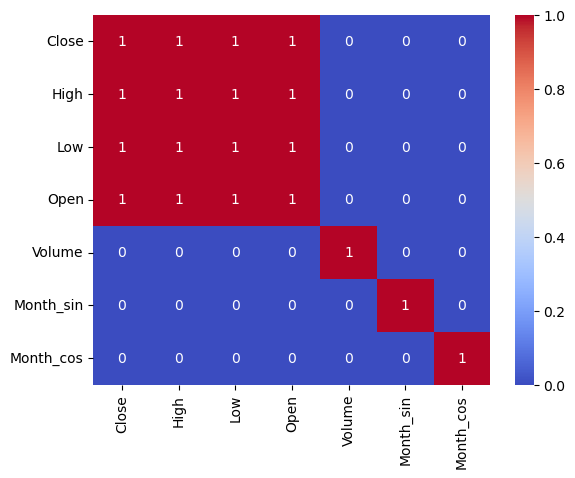

In [22]:
sns.heatmap(abs(x.corr())>0.7,annot=True,cmap="coolwarm")
plt.show()

In [23]:
x.drop(['Open'], axis=1,inplace=True)

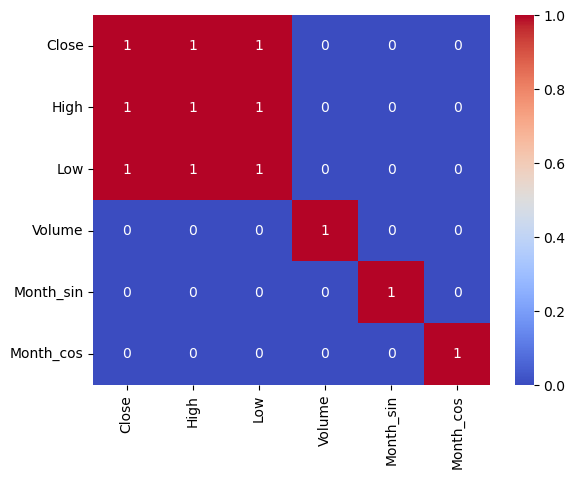

In [24]:
sns.heatmap(abs(x.corr())>0.7,annot=True,cmap="coolwarm")
plt.show()

### Scaling

In [25]:
from sklearn.preprocessing import StandardScaler

In [26]:
scale=StandardScaler()

In [27]:
scale_data=scale.fit_transform(x)

In [28]:
scale_data=pd.DataFrame(scale_data,columns=x.columns)

### Splitting

In [29]:
from sklearn.model_selection import train_test_split

In [30]:
x_train,x_test,y_train,y_test=train_test_split(scale_data,y,test_size=0.2,random_state=100)

### Build Model

In [31]:
from sklearn.linear_model import LinearRegression

In [32]:
model=LinearRegression()

In [33]:
model.fit(x_train,y_train)

LinearRegression()

In [34]:
y_pre=model.predict(x_test)

### Model Evaluation

In [35]:
from sklearn.metrics import r2_score,mean_absolute_error,mean_squared_error

In [36]:
r2score=r2_score(y_test,y_pre)
r2score

0.9972856677403703

In [37]:
MAE=mean_absolute_error(y_test,y_pre)
MSE=mean_squared_error(y_test,y_pre)
RMSE=mean_squared_error(y_test,y_pre,squared=False)
print(MAE,MSE,RMSE)

61.55216603851567 8371.471006439802 91.4957431055664


C:\Users\ABHIJEET CHANDRA\anaconda3\Lib\site-packages\sklearn\metrics\_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


### Prediction

In [38]:
x_test.head()

,Close,High,Low,Volume,Month_sin,Month_cos
521,-0,-0,-0,-0,1,1
1304,2,2,1,1,1,-1
725,0,0,0,0,-0,1
191,-1,-1,-1,-0,-1,1
479,-0,-0,-0,3,-0,1


In [39]:
import numpy as np
from datetime import datetime

# Example values
today_close = 707
today_high = 711
today_low = 663
today_volume = 2623577

# Transform volume using log1p (same as training)

today_volume = np.log1p(today_volume)




# Extract month info
today_date = datetime(2025, 8, 20)
month = today_date.month
month_sin = np.sin(2 * np.pi * month / 12)
month_cos = np.cos(2 * np.pi * month / 12)


In [40]:
input_data = pd.DataFrame([[today_close, today_high, today_low, today_volume, month_sin, month_cos]],
                          columns=['Close', 'High', 'Low', 'Volume', 'Month_sin', 'Month_cos'])


In [41]:
input_data

,Close,High,Low,Volume,Month_sin,Month_cos
0,707,711,663,15,-1,-1


In [42]:
input_scaled = scale.transform(input_data)  # Use the same scaler object
input_scaled

array([[ 3.69937245,  3.56256011,  3.51440814,  2.63242915, -1.27507   ,
        -0.65605176]])

In [43]:
predicted_close = model.predict(input_scaled)
print("Predicted Next Day Close:", predicted_close[0])

Predicted Next Day Close: 708.6583952107802


C:\Users\ABHIJEET CHANDRA\anaconda3\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


In [303]:
original_value = np.expm1(predicted_close)
original_value

C:\Users\ABHIJEET CHANDRA\AppData\Local\Temp\ipykernel_24784\3123950490.py:1: RuntimeWarning: overflow encountered in expm1
  original_value = np.expm1(predicted_close)


array([inf])

# predict high for a day

In [45]:
x1= data.drop(['High', 'Next_Close'], axis=1)
y1 = data['High']

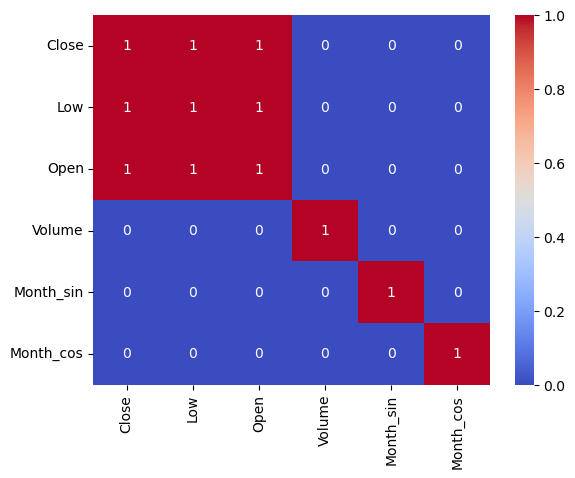

In [46]:
sns.heatmap(abs(x1.corr())>0.7,annot=True,cmap="coolwarm")
plt.show()

In [190]:
x1.drop(['Open'], axis=1,inplace=True)

In [137]:
from sklearn.preprocessing import StandardScaler

In [192]:
scale=StandardScaler()

In [193]:
scale_data1=scale.fit_transform(x1)

In [194]:
scale_data1=pd.DataFrame(scale_data1,columns=x1.columns)

In [195]:
scale_data1.head()

,Close,Low,Volume,Month_sin,Month_cos
0,-1,-1,2,1,1
1,-1,-1,1,1,1
2,-1,-1,0,1,1
3,-1,-1,1,1,1
4,-1,-1,1,1,1


In [196]:
from sklearn.model_selection import train_test_split

In [197]:
x_train,x_test,y_train,y_test=train_test_split(scale_data1,y1,test_size=0.2,random_state=100)

In [198]:
from sklearn.linear_model import LinearRegression

In [199]:
model1=LinearRegression()

In [200]:
model1.fit(x_train,y_train)

LinearRegression()

In [201]:
y_pree=model1.predict(x_test)

In [202]:
from sklearn.metrics import r2_score,mean_absolute_error,mean_squared_error

In [203]:
r2score1=r2_score(y_test,y_pree)
r2score1

0.998599332265242

In [204]:
MAE1=mean_absolute_error(y_test,y_pree)
MSE1=mean_squared_error(y_test,y_pree)
RMSE1=mean_squared_error(y_test,y_pree,squared=False)
print(MAE1,MSE1,RMSE1)

0.8469817094226684 4.57525650014404 2.138984922841683


C:\Users\ABHIJEET CHANDRA\anaconda3\Lib\site-packages\sklearn\metrics\_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


### Predict

In [44]:
import numpy as np

today_close = 134
today_low = 132
today_volume = 6919490
today_volume = np.log1p(today_volume)

# Date to month encoding
from datetime import datetime
today_date = datetime(2025, 7, 18)
month = today_date.month
month_sin = np.sin(2 * np.pi * month / 12)
month_cos = np.cos(2 * np.pi * month / 12)

In [206]:
input_data1 = pd.DataFrame([[today_close, today_low, today_volume, month_sin, month_cos]],
                          columns=['Close', 'Low', 'Volume', 'Month_sin', 'Month_cos'])

In [207]:
input_scaled1 = scale.transform(input_data1)
input_scaled1

array([[ 1.06278953,  1.07037745, -0.75849518, -0.77475931, -1.15818073]])

In [208]:
predicted_high1 = model1.predict(input_scaled1)
print("Predicted High:", predicted_high1[0])

Predicted High: 136.29599214675042


C:\Users\ABHIJEET CHANDRA\anaconda3\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


### new

In [44]:
data.head()

,Close,High,Low,Open,Volume,Month_sin,Month_cos,Next_Close
0,45,46,45,46,11,0,1,47
1,47,48,45,45,12,0,1,46
2,46,48,45,47,11,0,1,44
3,44,46,43,46,11,0,1,44
4,44,45,44,44,11,0,1,44


In [45]:
df=data.copy()


In [46]:
df['Next_High'] = df['High'].shift(-1)
df.dropna(inplace=True)  # Removes the last row with no next day


In [47]:
x2= df.drop(['High', 'Next_Close',"Next_High"], axis=1)
y2= df['Next_High']

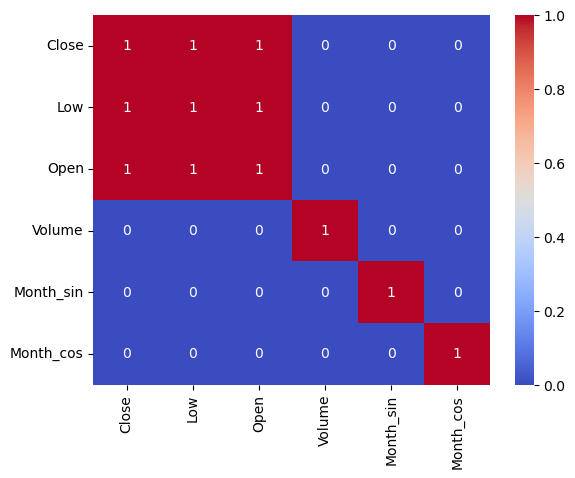

In [48]:
sns.heatmap(abs(x2.corr())>0.7,annot=True,cmap="coolwarm")
plt.show()

In [49]:
x2.drop(['Low'], axis=1,inplace=True)

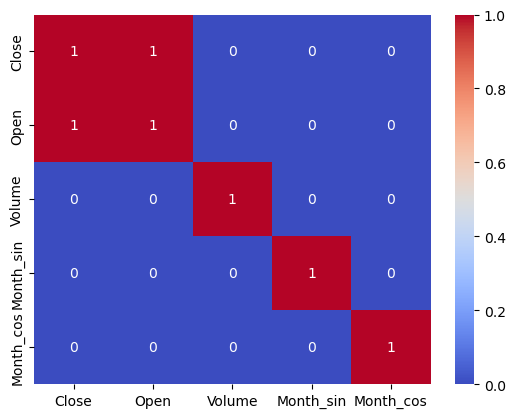

In [50]:
sns.heatmap(abs(x2.corr())>0.7,annot=True,cmap="coolwarm")
plt.show()

In [51]:
from sklearn.preprocessing import StandardScaler

In [52]:
scale=StandardScaler()

In [53]:
scale_data2=scale.fit_transform(x2)

In [54]:
scale_data2=pd.DataFrame(scale_data2,columns=x2.columns)

In [55]:
from sklearn.model_selection import train_test_split

In [56]:
x_train,x_test,y_train,y_test=train_test_split(scale_data2,y2,test_size=0.2,random_state=100)

In [57]:
from sklearn.linear_model import LinearRegression

In [58]:
model2=LinearRegression()

In [59]:
model2.fit(x_train,y_train)

LinearRegression()

In [60]:
y_pree2=model2.predict(x_test)

In [61]:
from sklearn.metrics import r2_score,mean_absolute_error,mean_squared_error

In [62]:
r2score2=r2_score(y_test,y_pree2)
r2score2

0.9963860858865221

In [63]:
MAE2=mean_absolute_error(y_test,y_pree2)
MSE2=mean_squared_error(y_test,y_pree2)
RMSE2=mean_squared_error(y_test,y_pree2,squared=False)
print(MAE2,MSE2,RMSE2)

4.095768242551001 67.80032371813796 8.234095197296298


C:\Users\ABHIJEET CHANDRA\anaconda3\Lib\site-packages\sklearn\metrics\_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


In [64]:
scale_data2.head()

,Close,Open,Volume,Month_sin,Month_cos
0,-1,-1,-1,1,1
1,-1,-1,0,1,1
2,-1,-1,-0,1,1
3,-1,-1,-0,1,1
4,-1,-1,-1,1,1


In [65]:
from datetime import datetime
import numpy as np
import pandas as pd

# Today's values
close = 707
Open = 669
volume = np.log1p(2623577)

# Date handling
today = datetime(2025, 8, 20)
month = today.month
month_sin = np.sin(2 * np.pi * month / 12)
month_cos = np.cos(2 * np.pi * month / 12)

In [66]:
input_data2 = pd.DataFrame([[close, Open, volume, month_sin, month_cos]],
                          columns=['Close', 'Open', 'Volume', 'Month_sin', 'Month_cos'])

In [67]:
input_scaled2 = scale.transform(input_data2)


In [68]:
predicted_next_high = model2.predict(input_scaled2)
print("Predicted High for 22nd July:", predicted_next_high[0])

Predicted High for 22nd July: 731.550343998847


C:\Users\ABHIJEET CHANDRA\anaconda3\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


In [257]:
original_value = np.expm1(predicted_next_high)
original_value

C:\Users\ABHIJEET CHANDRA\AppData\Local\Temp\ipykernel_27232\323002779.py:1: RuntimeWarning: overflow encountered in expm1
  original_value = np.expm1(predicted_next_high)


array([inf])

### Predict Low

In [38]:
dg=data.copy()


In [39]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [40]:
dg

,Close,High,Low,Open,Volume,Month_sin,Month_cos,Next_Close
0,"6,040","6,055","6,001","6,020",7,0,1,"6,030"
1,"6,030","6,061","6,014","6,014",8,0,1,"6,016"
2,"6,016","6,065","5,996","6,030",8,0,1,"6,035"
3,"6,035","6,054","5,987","6,054",8,0,1,"6,000"
4,"6,000","6,049","5,969","6,035",8,0,1,"5,903"
...,...,...,...,...,...,...,...,...
1462,"8,406","8,457","8,320","8,450",10,-1,1,"8,428"
1463,"8,428","8,472","8,364","8,449",10,-1,1,"8,763"
1464,"8,763","9,065","8,448","8,486",13,-1,1,"8,684"
1465,"8,684","8,764","8,600","8,763",10,-1,1,"8,578"


In [41]:
dg['Next_Low'] = dg['Low'].shift(-1)
dg.dropna(inplace=True)  # Removes the last row with no next day

In [42]:
dg

,Close,High,Low,Open,Volume,Month_sin,Month_cos,Next_Close,Next_Low
0,"6,040","6,055","6,001","6,020",7,0,1,"6,030","6,014"
1,"6,030","6,061","6,014","6,014",8,0,1,"6,016","5,996"
2,"6,016","6,065","5,996","6,030",8,0,1,"6,035","5,987"
3,"6,035","6,054","5,987","6,054",8,0,1,"6,000","5,969"
4,"6,000","6,049","5,969","6,035",8,0,1,"5,903","5,882"
...,...,...,...,...,...,...,...,...,...
1461,"8,446","8,465","8,276","8,276",10,-1,1,"8,406","8,320"
1462,"8,406","8,457","8,320","8,450",10,-1,1,"8,428","8,364"
1463,"8,428","8,472","8,364","8,449",10,-1,1,"8,763","8,448"
1464,"8,763","9,065","8,448","8,486",13,-1,1,"8,684","8,600"


In [43]:
x3= dg.drop(['Low', 'Next_Close',"Next_Low"], axis=1)
y3= dg['Next_Low']

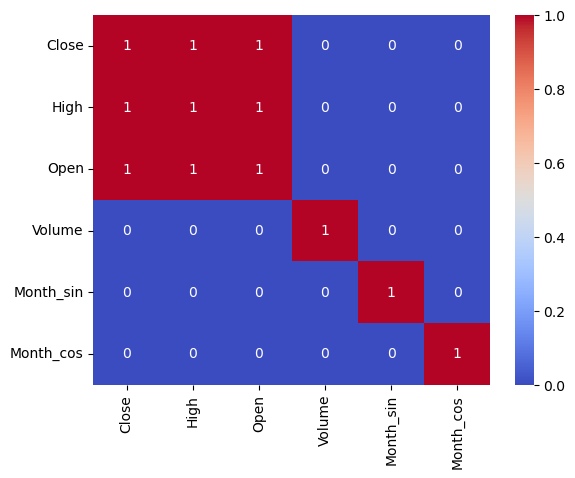

In [44]:
sns.heatmap(abs(x3.corr())>0.7,annot=True,cmap="coolwarm")
plt.show()

In [45]:
x3.drop("Open",axis=1,inplace=True)

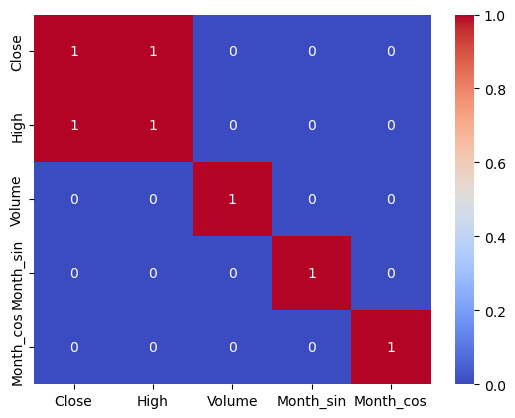

In [46]:
sns.heatmap(abs(x3.corr())>0.7,annot=True,cmap="coolwarm")
plt.show()

In [47]:
from sklearn.preprocessing import StandardScaler

In [48]:
scale=StandardScaler()

In [49]:
scale_data3=scale.fit_transform(x3)

In [50]:
scale_data3=pd.DataFrame(scale_data3,columns=x3.columns)

In [51]:
from sklearn.model_selection import train_test_split

In [52]:
x_train,x_test,y_train,y_test=train_test_split(scale_data3,y3,test_size=0.2,random_state=100)

In [53]:
from sklearn.linear_model import LinearRegression

In [54]:
model3=LinearRegression()

In [55]:
model3.fit(x_train,y_train)

LinearRegression()

In [56]:
y_pree3=model3.predict(x_test)

In [57]:
from sklearn.metrics import r2_score,mean_absolute_error,mean_squared_error

In [58]:
r2score3=r2_score(y_test,y_pree3)
r2score3

0.9984381419250612

In [59]:
MAE3=mean_absolute_error(y_test,y_pree3)
MSE3=mean_squared_error(y_test,y_pree3)
RMSE3=mean_squared_error(y_test,y_pree3,squared=False)
print(MAE3,MSE3,RMSE3)

48.299509929851126 4763.841355772089 69.02058646354789


C:\Users\ABHIJEET CHANDRA\anaconda3\Lib\site-packages\sklearn\metrics\_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


In [91]:
from datetime import datetime
import numpy as np
import pandas as pd

# Today's values
close = 707
High = 711
volume = np.log1p(2623577)

# Date handling
today = datetime(2025, 8, 20)
month = today.month
month_sin = np.sin(2 * np.pi * month / 12)
month_cos = np.cos(2 * np.pi * month / 12)

In [92]:
input_data3 = pd.DataFrame([[close, High, volume, month_sin, month_cos]],
                          columns=['Close', 'High', 'Volume', 'Month_sin', 'Month_cos'])

In [93]:
input_scaled3 = scale.transform(input_data3)


In [94]:
predicted_next_high = model3.predict(input_scaled3)
print("Predicted High for 22nd July:", predicted_next_high[0])

Predicted High for 22nd July: 689.94001353162


C:\Users\ABHIJEET CHANDRA\anaconda3\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


In [135]:
original_value = np.expm1(predicted_next_high)
original_value

C:\Users\ABHIJEET CHANDRA\AppData\Local\Temp\ipykernel_15260\323002779.py:1: RuntimeWarning: overflow encountered in expm1
  original_value = np.expm1(predicted_next_high)


array([inf])